# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SaaDasim05/Flyrank-ML-Internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

### Action mapping

| Observed situation | Action | Reason code |
|---|---|---|
| Strong negative trend + meaningful historical visibility | Review for refresh | `DECLINE_REVIEW` |
| Visible content where depth/content coverage deserves investigation | Review content depth | `DEPTH_REVIEW` |
| Weak or insufficient evidence | Monitor | `MONITOR` |

### Decay / refresh insight

The FlyRank research paper reports that content health was strongest around 61–90 days and declined in later age bands. It also reports that older content that was recently refreshed could perform similarly to younger, recently refreshed content. These are observational portfolio findings, not proof that age or refreshing alone causes performance changes.

For this playbook, age and freshness are therefore treated as review signals rather than automatic refresh triggers.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

### Intended use

The model output is intended to prioritize content items for human review. Higher-scoring items should be reviewed earlier when the team has limited time.

### Limits

The score is a decision-support signal, not proof that a page needs a refresh or that refreshing it will improve search performance.

The validation was performed on a limited future window and client-group split, so the measured performance should be treated as directional.

The model also produces false positives and false negatives, so individual recommendations require human review.

### Cost/value

A high-priority review is most useful when the potential value of protecting existing search visibility justifies the time required to investigate and act.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

### Human review

Before acting on a high score, a reviewer should check:

- whether the decline is supported by sufficient historical data;
- whether the page still serves an important intent;
- whether the content is actually outdated or incomplete;
- whether another explanation could account for the observed change;
- whether the proposed action is proportionate.

### Do not automate

The score should not automatically:

- publish rewritten content;
- delete or consolidate a page;
- declare content "bad";
- change search intent;
- claim that a refresh will increase traffic;
- trigger a major content decision without review.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Monitor:

- Precision@50 on new future windows;
- performance across clients;
- false-positive and false-negative patterns;
- feature distributions;
- missing-data rates.

Review or retrain when performance deteriorates materially, data availability changes, feature distributions shift, or the outcome definition changes.

A changed score alone is not sufficient reason to retrain.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Warehouse ready.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Random split Precision@50: 0.760
Client-group Precision@50: 0.680
Ranked queue rows: 20,768


,rank,client_hash_id,content_hash_id,model_score,action,reason_code,impressions_march,avg_position_march,days_since_update,word_count
0,1,client_65de48885f4ef01b,content_192d903c68674e57,1.000000,Review for refresh,DECLINE_REVIEW,3.0,4.333333,0,1328
1,2,client_65de48885f4ef01b,content_1bd58570e2cbccfc,1.000000,Review for refresh,DECLINE_REVIEW,2.0,4.500000,0,1132
2,3,client_65de48885f4ef01b,content_440cabf60d53be31,0.993333,Review for refresh,DECLINE_REVIEW,3.0,2.333333,0,1371
3,4,client_c182d11e4862a37d,content_014aac56410f2cb2,0.986667,Review for refresh,DECLINE_REVIEW,1.0,9.000000,0,1014
4,5,client_def0955f7a377868,content_1326c6bb2d663a7d,0.983333,Review for refresh,DECLINE_REVIEW,2.0,6.000000,0,1665
5,6,client_fef1a8f436438636,content_4dd22c70f1b787a2,0.980000,Review for refresh,DECLINE_REVIEW,225.0,4.408417,0,1471
6,7,client_fef1a8f436438636,content_730dcc23f41c4f5a,0.980000,Review for refresh,DECLINE_REVIEW,224.0,4.727814,0,1514
7,8,client_fef1a8f436438636,content_107e27c3be4dad46,0.980000,Review for refresh,DECLINE_REVIEW,216.0,5.600154,0,1467
8,9,client_65de48885f4ef01b,content_b9a053160d20e37c,0.980000,Review for refresh,DECLINE_REVIEW,12.0,24.687500,0,1386
9,10,client_def0955f7a377868,content_e74c83a3014dcac1,0.980000,Review for refresh,DECLINE_REVIEW,4.0,7.166667,0,1688


Queue written to: ../outputs/capstone_ranked_action_queue.csv


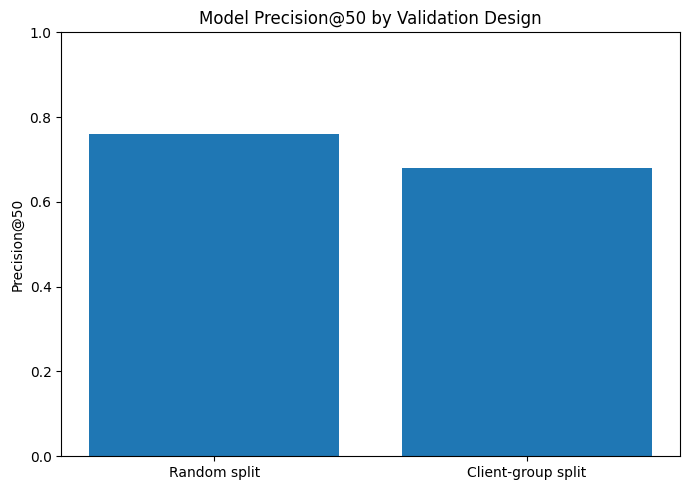

Figure written to: ../figures/validation_precision_at_50.png
Metrics receipt written to: ../outputs/w07_metrics.json


In [3]:
# =========================================================
# 5. Exports for the paper
# Self-contained version
# =========================================================

import os
import json
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import userdata
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GroupShuffleSplit


# ---------------------------------------------------------
# 1. Connect to the warehouse if needed
# ---------------------------------------------------------

if "con" not in globals() or "TABLES" not in globals():

    HF_TOKEN = userdata.get("HF_TOKEN")

    if not HF_TOKEN:
        raise ValueError("HF_TOKEN not found in Colab Secrets.")

    con = duckdb.connect()

    con.execute(f"""
        CREATE OR REPLACE SECRET hf (
            TYPE HUGGINGFACE,
            TOKEN '{HF_TOKEN}'
        )
    """)

    REL = "hf://datasets/FlyRank/internship-warehouse"

    TABLES = {
        "fact_daily":
            f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')"
    }

else:
    REL = "hf://datasets/FlyRank/internship-warehouse"


print("Warehouse ready.")


# ---------------------------------------------------------
# 2. Build March features
# ---------------------------------------------------------

march = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS impressions_march,
        SUM(gsc_clicks) AS clicks_march,

        AVG(
            CASE
                WHEN gsc_data_available IS TRUE
                THEN gsc_avg_position
            END
        ) AS avg_position_march,

        SUM(sessions_organic) AS organic_sessions_march,

        COUNT(DISTINCT report_date) FILTER (
            WHERE gsc_impressions > 0
        ) AS days_with_impressions_march

    FROM {TABLES['fact_daily']}

    WHERE report_date >= DATE '2026-03-01'
      AND report_date < DATE '2026-04-01'

    GROUP BY 1, 2
""").df()


# ---------------------------------------------------------
# 3. Build April future outcome
# ---------------------------------------------------------

april = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS impressions_april

    FROM {TABLES['fact_daily']}

    WHERE report_date >= DATE '2026-04-01'
      AND report_date < DATE '2026-05-01'

    GROUP BY 1, 2
""").df()


data = march.merge(
    april,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

data["is_declining"] = (
    data["impressions_april"]
    < 0.8 * data["impressions_march"]
).astype(int)


# ---------------------------------------------------------
# 4. Add content metadata
# ---------------------------------------------------------

content_dates = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        content_updated_date,
        word_count
    FROM read_parquet('{REL}/dim_content.parquet')
""").df()

content_dates["content_updated_date"] = pd.to_datetime(
    content_dates["content_updated_date"],
    errors="coerce"
)

decision_date = pd.Timestamp("2026-03-31")

content_dates["days_since_update"] = (
    decision_date - content_dates["content_updated_date"]
).dt.days.clip(lower=0)

data = data.merge(
    content_dates[
        [
            "client_hash_id",
            "content_hash_id",
            "days_since_update",
            "word_count"
        ]
    ],
    on=["client_hash_id", "content_hash_id"],
    how="left"
)


# ---------------------------------------------------------
# 5. Final feature set
# ---------------------------------------------------------

model_features = [
    "impressions_march",
    "clicks_march",
    "avg_position_march",
    "organic_sessions_march",
    "days_with_impressions_march",
    "days_since_update",
    "word_count"
]

model_df = data.dropna(
    subset=model_features + [
        "is_declining",
        "client_hash_id"
    ]
).copy()

X = model_df[model_features]
y = model_df["is_declining"]
groups = model_df["client_hash_id"]


# ---------------------------------------------------------
# 6. Random split (for comparison figure)
# ---------------------------------------------------------

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

random_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

random_model.fit(X_train_r, y_train_r)

random_scores = random_model.predict_proba(
    X_test_r
)[:, 1]


# ---------------------------------------------------------
# 7. Client-group split
# ---------------------------------------------------------

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_group_train = X.iloc[train_idx]
X_group_test = X.iloc[test_idx]

y_group_train = y.iloc[train_idx]
y_group_test = y.iloc[test_idx]

group_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

group_model.fit(
    X_group_train,
    y_group_train
)

group_scores = group_model.predict_proba(
    X_group_test
)[:, 1]


# ---------------------------------------------------------
# 8. Precision@50
# ---------------------------------------------------------

def precision_at_k(scores, labels, k=50):
    scores = np.asarray(scores)
    labels = np.asarray(labels)

    order = np.argsort(-scores)[:k]

    return labels[order].mean()


random_p50 = precision_at_k(
    random_scores,
    y_test_r,
    50
)

group_p50 = precision_at_k(
    group_scores,
    y_group_test,
    50
)

print(f"Random split Precision@50: {random_p50:.3f}")
print(f"Client-group Precision@50: {group_p50:.3f}")


# ---------------------------------------------------------
# 9. Build ranked queue from held-out clients
# ---------------------------------------------------------

paper_queue = model_df.iloc[test_idx].copy()

paper_queue["model_score"] = group_scores

paper_queue = (
    paper_queue
    .sort_values(
        ["model_score", "impressions_march"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

paper_queue["rank"] = np.arange(
    1,
    len(paper_queue) + 1
)

paper_queue["action"] = np.where(
    paper_queue["model_score"] >= 0.50,
    "Review for refresh",
    "Monitor"
)

paper_queue["reason_code"] = np.where(
    paper_queue["model_score"] >= 0.50,
    "DECLINE_REVIEW",
    "MONITOR"
)

paper_queue = paper_queue[
    [
        "rank",
        "client_hash_id",
        "content_hash_id",
        "model_score",
        "action",
        "reason_code",
        "impressions_march",
        "avg_position_march",
        "days_since_update",
        "word_count"
    ]
]

print(f"Ranked queue rows: {len(paper_queue):,}")

display(
    paper_queue.head(20)
)


# ---------------------------------------------------------
# 10. Export queue
# ---------------------------------------------------------

output_dir = Path("../outputs")
output_dir.mkdir(
    parents=True,
    exist_ok=True
)

queue_path = (
    output_dir /
    "capstone_ranked_action_queue.csv"
)

paper_queue.to_csv(
    queue_path,
    index=False
)

print(f"Queue written to: {queue_path}")


# ---------------------------------------------------------
# 11. Export validation figure
# ---------------------------------------------------------

figure_dir = Path("../figures")
figure_dir.mkdir(
    parents=True,
    exist_ok=True
)

plt.figure(figsize=(7, 5))

plt.bar(
    ["Random split", "Client-group split"],
    [random_p50, group_p50]
)

plt.ylabel("Precision@50")
plt.title("Model Precision@50 by Validation Design")
plt.ylim(0, 1)

plt.tight_layout()

figure_path = (
    figure_dir /
    "validation_precision_at_50.png"
)

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(f"Figure written to: {figure_path}")


# ---------------------------------------------------------
# 12. Export metrics receipt
# ---------------------------------------------------------

metrics = {
    "model": "Random Forest",
    "feature_window": "March 2026",
    "outcome_window": "April 2026",
    "target": "April impressions < 80% of March impressions",
    "validation": "GroupShuffleSplit by client_hash_id",
    "random_split_precision_at_50": round(
        float(random_p50), 4
    ),
    "client_group_precision_at_50": round(
        float(group_p50), 4
    ),
    "training_clients": int(
        model_df.iloc[train_idx][
            "client_hash_id"
        ].nunique()
    ),
    "testing_clients": int(
        model_df.iloc[test_idx][
            "client_hash_id"
        ].nunique()
    ),
    "testing_rows": int(
        len(y_group_test)
    )
}

metrics_path = (
    output_dir /
    "w07_metrics.json"
)

with open(metrics_path, "w") as f:
    json.dump(
        metrics,
        f,
        indent=2
    )

print(f"Metrics receipt written to: {metrics_path}")

### Paper-ready exports

The notebook regenerates the ranked action queue and validation figure used by the capstone paper.

The ranked queue is a generated data artifact and remains outside Git according to the repository's data guard. The metrics JSON and reusable validation figure are the paper's traceable run receipts.

## Self-check

Before you submit, confirm each line honestly:

- [X] Every section above is filled — markdown thinking AND the code that backs it
- [X] The notebook runs top to bottom with no errors (Runtime → Run all)
- [X] No client names, URLs, or private queries anywhere
- [X] My claims use careful words: observed, measured, directional, decision-support
- [X] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.